In [90]:
import cv2
import fitz
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import subprocess
import re
import string
from pathlib import Path
from types import SimpleNamespace
from collections import defaultdict
from scipy.ndimage import uniform_filter
from scipy.special import logsumexp

try:
    import pytesseract
    TESSERACT_AVAILABLE = True
    print('pytesseract available — OCR fallback enabled')
except ImportError:
    TESSERACT_AVAILABLE = False
    print('pytesseract not found — only fitz text extraction will be used')

pytesseract available — OCR fallback enabled


In [91]:
VIDEO_PATH = Path('data/query_planning.mp4')
PDF_PATH   = Path('data/query_planning.pdf')
TXT_PATH   = Path('data/query_planning.txt')

TARGET_SIZE      = (128, 128)
TARGET_W, TARGET_H = TARGET_SIZE

DIFF_THRESHOLD   = 1.0        # frame grouping: max mean pixel diff to merge

TOP_K            = 3          # visual: keep top-K slides by L1 distance

P_WORD_IN_SLIDE  = 0.66
P_WORD_NOT_SLIDE = 0.33
MIN_WORD_LEN     = 3

B = 0.1   # P(stay on same slide) per group step

STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is',
    'are','was','were','be','been','being','have','has','had','do','does',
    'did','will','would','shall','should','may','might','can','could',
    'not','no','nor','so','yet','both','either','neither','just','also',
    'that','this','these','those','it','its','we','our','you','your',
    'he','she','they','them','then','than','with','from','into','through',
    'about','what','which','who','how','when','where','why','if','as',
    'by','up','out','over','some','all','each','every','more','other',
    'there','their','here'
}

In [92]:
# ── Parse transcript timestamps ────────────────────────────────────────────────
# Reads query_planning.txt produced by transcribe.py.
# Output: segments — sorted list of SimpleNamespace(.start, .end, .text)

_TS_RE = re.compile(r'\[(\d{2}:\d{2}:\d{2}\.\d+) --> (\d{2}:\d{2}:\d{2}\.\d+)\]')

def ts_to_sec(ts: str) -> float:
    h, m, s = ts.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)

segments = []
cur_start = cur_end = None
text_lines = []

with open(TXT_PATH, 'r') as fh:
    for line in fh:
        line = line.rstrip('\n')
        m = _TS_RE.match(line)
        if m:
            if cur_start is not None and text_lines:
                segments.append(SimpleNamespace(
                    start=cur_start, end=cur_end,
                    text=' '.join(text_lines)
                ))
            cur_start = ts_to_sec(m.group(1))
            cur_end   = ts_to_sec(m.group(2))
            text_lines = []
        elif line.strip() and cur_start is not None:
            text_lines.append(line.strip())

if cur_start is not None and text_lines:
    segments.append(SimpleNamespace(start=cur_start, end=cur_end,
                                    text=' '.join(text_lines)))

segments.sort(key=lambda s: s.start)
n_segs    = len(segments)
seg_times = np.array([s.start for s in segments])

print(f'Parsed {n_segs} segments  ({seg_times[0]:.1f}s – {seg_times[-1]:.1f}s)')


Parsed 757 segments  (0.0s – 5391.4s)


In [ ]:
# ── AOI calibration + raw frame extraction ────────────────────────────────────
# Stage 1 (temporary): Sobel + Hough on 10 sampled frames -> median crop corner.
# Stage 2: for every frame: extract BGR -> crop to slide AOI -> convert to
#   grayscale.  No resizing yet — that happens after grouping and OCR.
#
# Output:
#   frames_raw : list of (H, W) uint8 full-resolution grayscale crops, or None

def _extract_frame_bgr(video_path: Path, timestamp: float):
    cmd = ['ffmpeg', '-y', '-ss', str(timestamp), '-i', str(video_path),
           '-frames:v', '1', '-f', 'image2pipe', '-vcodec', 'png', 'pipe:1']
    r = subprocess.run(cmd, capture_output=True)
    if r.returncode != 0 or not r.stdout:
        return None
    return cv2.imdecode(np.frombuffer(r.stdout, dtype=np.uint8), cv2.IMREAD_COLOR)

def _find_aoi_corner(bgr, ksize=3, threshold=80, angle_tol=6):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    sx  = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=ksize)
    sy  = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=ksize)
    sx2 = cv2.Sobel(np.abs(sx), cv2.CV_64F, 1, 0, ksize=ksize)
    sy2 = cv2.Sobel(np.abs(sy), cv2.CV_64F, 0, 1, ksize=ksize)
    bx = cv2.threshold(cv2.convertScaleAbs(sx + 3*sx2), threshold, 255, cv2.THRESH_BINARY)[1]
    by = cv2.threshold(cv2.convertScaleAbs(sy + 3*sy2), threshold, 255, cv2.THRESH_BINARY)[1]
    kv = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    kh = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    closed = cv2.bitwise_or(cv2.morphologyEx(bx, cv2.MORPH_CLOSE, kv),
                             cv2.morphologyEx(by, cv2.MORPH_CLOSE, kh))
    lines = cv2.HoughLinesP(closed, 1, np.pi/180, 40, minLineLength=40, maxLineGap=50)
    h_lines, v_lines = [], []
    if lines is not None:
        for l in lines:
            x1, y1, x2, y2 = l[0]
            length = np.hypot(x2-x1, y2-y1)
            if abs(y2-y1) <= angle_tol:   h_lines.append((length, l[0]))
            elif abs(x2-x1) <= angle_tol: v_lines.append((length, l[0]))
    h_lines.sort(key=lambda t: -t[0]); v_lines.sort(key=lambda t: -t[0])
    cx = int((v_lines[0][1][0]+v_lines[0][1][2])/2) if v_lines else None
    cy = int((h_lines[0][1][1]+h_lines[0][1][3])/2) if h_lines else None
    return cx, cy

# — Calibrate crop corner from 10 evenly-spaced frames —
calib_idx = np.linspace(0, n_segs-1, 10, dtype=int)
cx_vals, cy_vals = [], []
print('Calibrating AOI corner ...')
for i in calib_idx:
    bgr = _extract_frame_bgr(VIDEO_PATH, segments[i].start)
    if bgr is None: continue
    cx, cy = _find_aoi_corner(bgr)
    if cx is not None: cx_vals.append(cx)
    if cy is not None: cy_vals.append(cy)

crop_x = int(np.median(cx_vals)) if cx_vals else 0
crop_y = int(np.median(cy_vals)) if cy_vals else 0
print(f'  crop corner: ({crop_x}, {crop_y})  from {len(cx_vals)}/10 frames')

# — Extract all frames: crop -> grayscale (full resolution, no resize yet) —
print(f'Extracting {n_segs} frames ...')
frames_raw = []   # (H, W) uint8 full-res grayscale, or None

for seg in segments:
    bgr = _extract_frame_bgr(VIDEO_PATH, seg.start)
    if bgr is None:
        frames_raw.append(None)
        continue
    h, w = bgr.shape[:2]
    roi  = bgr[crop_y:h, crop_x:w]
    frames_raw.append(cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY))

print(f'  {sum(f is not None for f in frames_raw)}/{n_segs} extracted ok')
h0, w0 = next(f for f in frames_raw if f is not None).shape
print(f'  Full-res crop size: {w0}x{h0} px')

In [ ]:
# ── Frame grouping: merge consecutive identical frames ────────────────────────
# Two adjacent segments belong to the same group when their full-res grayscale
# frames have mean |pixel diff| <= DIFF_THRESHOLD.
#
# Group data structure (frame_words added later by the OCR cell):
#   {
#     'seg_indices' : [int, ...]
#     'start_time'  : float
#     'end_time'    : float
#     'frame'       : np.ndarray  representative full-res grayscale crop (or None)
#     'words'       : [str, ...]  all spoken tokens in this group
#   }

def tokenize(text: str) -> list:
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return [w for w in text.split()
            if len(w) >= MIN_WORD_LEN and w not in STOPWORDS]

def frame_diff(f1, f2) -> float:
    if f1 is None or f2 is None:
        return float('inf')
    return float(np.mean(np.abs(f1.astype(np.int32) - f2.astype(np.int32))))

groups = []
for seg_idx, seg in enumerate(segments):
    frame = frames_raw[seg_idx]
    words = tokenize(seg.text)

    if groups and frame_diff(frame, groups[-1]['frame']) <= DIFF_THRESHOLD:
        g = groups[-1]
        g['seg_indices'].append(seg_idx)
        g['end_time'] = seg.end
        g['words'].extend(words)
        if g['frame'] is None and frame is not None:
            g['frame'] = frame
    else:
        groups.append({
            'seg_indices': [seg_idx],
            'start_time' : seg.start,
            'end_time'   : seg.end,
            'frame'      : frame,
            'words'      : words,
        })

n_groups     = len(groups)
group_starts = np.array([g['start_time'] for g in groups])
group_ends   = np.array([g['end_time']   for g in groups])

print(f'Frame grouping result:')
print(f'  {n_segs} segments  ->  {n_groups} groups  '
      f'(avg {n_segs/n_groups:.1f} segs/group)')
print(f'  Group durations: '
      f'min={np.min(group_ends-group_starts):.1f}s  '
      f'mean={np.mean(group_ends-group_starts):.1f}s  '
      f'max={np.max(group_ends-group_starts):.1f}s')
print(f'  Example group 0: segs={groups[0]["seg_indices"]}  '
      f'words={groups[0]["words"][:8]}')

In [ ]:
# ── OCR: extract words from each group's representative frame ─────────────────
# Now that groups are formed we only need to run pytesseract on the ONE
# representative (full-res grayscale) frame per group — not on every segment.
#
# Preprocessing pipeline for OCR:
#   1. Upscale to >= 600 px wide (improves character recognition on video frames)
#   2. Otsu binarisation (clean black-on-white text for tesseract)
#
# Result: g['frame_words'] added to every group dict.

def _ocr_gray(gray_frame) -> list:
    if not TESSERACT_AVAILABLE or gray_frame is None:
        return []
    h, w = gray_frame.shape
    scale = max(1, 600 // max(w, 1))
    big   = cv2.resize(gray_frame, (w * scale, h * scale),
                       interpolation=cv2.INTER_CUBIC) if scale > 1 else gray_frame
    _, thresh = cv2.threshold(big, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    text = pytesseract.image_to_string(thresh, lang='eng', config='--psm 6')
    return tokenize(text)

print(f'Running OCR on {n_groups} representative frames ...')
for g in groups:
    g['frame_words'] = _ocr_gray(g['frame'])

fw_lens = [len(g['frame_words']) for g in groups]
print(f'  done.')
print(f'  frame_words per group: '
      f'min={min(fw_lens)}  mean={sum(fw_lens)/len(fw_lens):.1f}  max={max(fw_lens)}')
print(f'  Example group 0 frame_words: {groups[0]["frame_words"][:10]}')

In [95]:
# ── Extract text from PDF slides ───────────────────────────────────────────────
# Pipeline:
#   1. fitz page.get_text()  — works for PDFs with embedded selectable text
#   2. pytesseract on the rendered page image  — fallback for image-only slides
#
# Output: slide_words_raw  — list of token lists, one per slide
#         slide_word_sets  — list of sets of unique tokens, one per slide
#
# Note: tesseract must be installed separately.
#   macOS: brew install tesseract

MIN_FITZ_CHARS = 30   # if fitz returns fewer characters, try OCR

def _ocr_page(page) -> str:
    """Render a fitz page to an image and run Tesseract OCR on it."""
    if not TESSERACT_AVAILABLE:
        return ''
    pix = page.get_pixmap(dpi=150)
    rgb = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)
    # Tesseract works better on slightly enlarged, clean images
    return pytesseract.image_to_string(rgb, lang='eng')

pdf = fitz.open(str(PDF_PATH))
n_slides = len(pdf)

# slide_texts_raw[s] = full raw string extracted from slide s
slide_texts_raw = []
extraction_method = []   # 'fitz' or 'ocr' — useful for debugging

for page in pdf:
    text = page.get_text('text')         # fitz native extraction
    if len(text.strip()) >= MIN_FITZ_CHARS:
        slide_texts_raw.append(text)
        extraction_method.append('fitz')
    else:
        ocr_text = _ocr_page(page)       # fallback: Tesseract OCR
        slide_texts_raw.append(ocr_text)
        extraction_method.append('ocr')

pdf.close()

# Tokenise each slide's text
slide_words_raw = [tokenize(t) for t in slide_texts_raw]   # list of lists
slide_word_sets = [set(w) for w in slide_words_raw]         # list of sets (fast lookup)

fitz_count = extraction_method.count('fitz')
print(f'Slide text extraction: {n_slides} slides')
print(f'  fitz: {fitz_count}   OCR: {n_slides - fitz_count}')
print(f'  Token counts per slide: '
      f'min={min(len(w) for w in slide_words_raw)}  '
      f'max={max(len(w) for w in slide_words_raw)}')
print(f'  Example slide 0 words: {slide_words_raw[0][:12]}')


Slide text extraction: 114 slides
  fitz: 114   OCR: 0
  Token counts per slide: min=9  max=102
  Example slide 0 words: ['data', 'integration', 'query', 'planning', 'global', 'view', 'local', 'view', 'felix', 'naumann']


In [96]:
# ── Build global vocabulary (BoW index) ────────────────────────────────────────
# The vocabulary is the UNION of:
#   - all tokenised words across all PDF slides
#   - all tokenised words across all transcript segments
#
# Data structures produced here:
#   vocab        : sorted list of unique tokens        len = V
#   word_to_idx  : dict { word → index }               len = V
#   slide_bow_matrix  : (n_slides, V) bool array
#                       slide_bow_matrix[s, w] = True iff word w is in slide s
#   group_bow_matrix  : (n_groups, V) bool array
#                       group_bow_matrix[g, w] = True iff word w was spoken in group g

# Collect all tokens from slides
all_slide_words = set().union(*slide_word_sets)

# Collect all tokens from transcript groups (already tokenised inside groups)
all_group_words = set()
for g in groups:
    all_group_words.update(g['words'])

# Union → global vocabulary
vocab       = sorted(all_slide_words | all_group_words)
V           = len(vocab)
word_to_idx = {w: i for i, w in enumerate(vocab)}

print(f'Vocabulary size: {V} tokens')
print(f'  from slides only      : {len(all_slide_words - all_group_words)}')
print(f'  from transcript only  : {len(all_group_words - all_slide_words)}')
print(f'  shared                : {len(all_slide_words & all_group_words)}')

# — slide_bow_matrix[s, v] = True if word vocab[v] appears on slide s —
slide_bow_matrix = np.zeros((n_slides, V), dtype=bool)
for s_idx, word_set in enumerate(slide_word_sets):
    for w in word_set:
        if w in word_to_idx:    # always true but guard is cheap
            slide_bow_matrix[s_idx, word_to_idx[w]] = True

# — group_bow_matrix[g, v] = True if word vocab[v] was spoken in group g —
group_bow_matrix = np.zeros((n_groups, V), dtype=bool)
for g_idx, g in enumerate(groups):
    for w in g['words']:
        if w in word_to_idx:
            group_bow_matrix[g_idx, word_to_idx[w]] = True

print(f'slide_bow_matrix  shape: {slide_bow_matrix.shape}')
print(f'group_bow_matrix  shape: {group_bow_matrix.shape}')
print(f'  avg words per slide : {slide_bow_matrix.sum(axis=1).mean():.1f}')
print(f'  avg words per group : {group_bow_matrix.sum(axis=1).mean():.1f}')


Vocabulary size: 1488 tokens
  from slides only      : 514
  from transcript only  : 622
  shared                : 352
slide_bow_matrix  shape: (114, 1488)
group_bow_matrix  shape: (104, 1488)
  avg words per slide : 29.4
  avg words per group : 37.0


In [ ]:
# ── Resize + normalise slides and group frames ────────────────────────────────
# Slides are rendered from PDF and resized to TARGET_SIZE.
# Group frames are already cropped grayscale (full-res); resize them here
# to the same TARGET_SIZE before normalisation and visual comparison.

def normalize_gray(arr: np.ndarray) -> np.ndarray:
    a = arr.astype(np.float32)
    s = a.std()
    return (a - a.mean()) / (s if s > 0 else 1.0)

def load_pdf_slides_raw(pdf_path):
    raw = []
    pdf = fitz.open(str(pdf_path))
    for page in pdf:
        pix = page.get_pixmap(dpi=72)
        rgb = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        raw.append(cv2.resize(gray, TARGET_SIZE, interpolation=cv2.INTER_LANCZOS4))
    pdf.close()
    return raw

slides_raw  = np.stack(load_pdf_slides_raw(PDF_PATH), axis=0)   # (S, H, W) uint8
n_slides    = len(slides_raw)
slides_norm = np.stack([normalize_gray(s) for s in slides_raw], axis=0)  # (S, H, W) float32

# Resize group frames from full-res crop to TARGET_SIZE, then normalise
group_frames_norm = [
    normalize_gray(cv2.resize(g['frame'], TARGET_SIZE, interpolation=cv2.INTER_LANCZOS4))
    if g['frame'] is not None else None
    for g in groups
]

print(f'Slides      : {slides_norm.shape}  dtype={slides_norm.dtype}')
print(f'Group frames: {sum(f is not None for f in group_frames_norm)}/{n_groups} available')

In [98]:
# ── Visual log-emission: L1 pixel distance, top-3 inverse-weighted ────────────
#
# For each group frame f and slide s:
#   dist[s] = Σ |f[y,x] − slide_norm[s,y,x]|   (L1 on z-score images)
#
# Keep only the TOP_K=3 slides with the SMALLEST distance.
# Weight each by the inverse of its distance → closer = higher probability:
#   w[s] = 1 / dist[s]
#   P_vis(g | s) = w[s] / Σ_{k ∈ top-3} w[k]   for s in top-3
#               = 0                               otherwise

log_emit_vis = np.full((n_groups, n_slides), -np.inf, dtype=np.float64)
l1_dists     = np.zeros((n_groups, n_slides), dtype=np.float64)

print(f'Computing visual emission ({n_groups} groups × {n_slides} slides) ...')

for g, frame in enumerate(group_frames_norm):
    if frame is None:
        log_emit_vis[g, :] = -np.log(n_slides)
        continue

    # L1 distance against every slide  (broadcast: (1,H,W) vs (S,H,W))
    diffs = np.abs(frame[np.newaxis] - slides_norm).sum(axis=(1, 2))   # (S,)
    l1_dists[g] = diffs

    # Indices of the TOP_K closest slides (smallest distance)
    top_idx  = np.argpartition(diffs, TOP_K)[:TOP_K]
    top_dist = diffs[top_idx]

    # Inverse-distance weights, normalised
    inv_w   = 1.0 / (top_dist + 1e-6)
    weights = inv_w / inv_w.sum()

    log_emit_vis[g, top_idx] = np.log(weights)

print('  done.')
emit_vis     = np.exp(log_emit_vis)
vis_row_sums = emit_vis.sum(axis=1)
print(f'  row sum check : min={vis_row_sums.min():.6f}  max={vis_row_sums.max():.6f}')

vis_entropy = np.where(emit_vis > 0, -emit_vis * np.log(emit_vis), 0.0).sum(axis=1)
print(f'  visual entropy: mean={vis_entropy.mean():.3f} nats  '
      f'(max for top-{TOP_K}: {np.log(TOP_K):.3f}  |  uniform over all: {np.log(n_slides):.3f})')

best_dist = l1_dists.max(axis=1)   # not used for ranking, just for sanity
print(f'  L1 distance to top-1 slide: '
      f'min={l1_dists.min(axis=1).min():.1f}  '
      f'mean={l1_dists.min(axis=1).mean():.1f}  '
      f'max={l1_dists.min(axis=1).max():.1f}')

Computing visual emission (104 groups × 114 slides) ...
  done.
  row sum check : min=1.000000  max=1.000000
  visual entropy: mean=1.059 nats  (max for top-3: 1.099  |  uniform over all: 4.736)
  L1 distance to top-1 slide: min=1720.1  mean=3938.4  max=7091.2


/var/folders/00/ghmcvj4s1psckq_yqh3czg100000gn/T/ipykernel_45739/823345511.py:41: RuntimeWarning: divide by zero encountered in log
  vis_entropy = np.where(emit_vis > 0, -emit_vis * np.log(emit_vis), 0.0).sum(axis=1)
/var/folders/00/ghmcvj4s1psckq_yqh3czg100000gn/T/ipykernel_45739/823345511.py:41: RuntimeWarning: invalid value encountered in multiply
  vis_entropy = np.where(emit_vis > 0, -emit_vis * np.log(emit_vis), 0.0).sum(axis=1)


In [99]:
# ── Text (BoW) log-emission matrix ────────────────────────────────────────────
#
# Bernoulli emission model:
#   For each OBSERVED word w in group g:
#     P(w observed | slide s) = P_WORD_IN_SLIDE  if w ∈ slide_word_sets[s]
#                              = P_WORD_NOT_SLIDE  otherwise
#
#   log P_text(group_g | slide_s)
#     = Σ_{w ∈ group_words_g} log P(w | slide_s)
#
# We only condition on OBSERVED words (words in the group), not on absent
# words, to keep the signal informative and avoid penalising for words
# from other slides that simply were not spoken yet.
#
# Vectorised implementation:
#   For group g, group_bow_matrix[g] is a bool (V,) mask of observed words.
#   slide_bow_matrix is (S, V).
#   For each observed word v, log_p[s, v] = log(0.66) if slide has word, else log(0.33).
#   Sum over observed words → log_raw[s] for all slides at once.

LOG_P_IN  = np.log(P_WORD_IN_SLIDE)    # log 0.66
LOG_P_OUT = np.log(P_WORD_NOT_SLIDE)   # log 0.33

# Precompute the full log-probability matrix: log_p_word[s, v] (float64)
#   = log(0.66) if slide s contains word v, else log(0.33)
# Shape: (n_slides, V)
log_p_word = np.where(slide_bow_matrix, LOG_P_IN, LOG_P_OUT).T   # (V, S) first, then
log_p_word = log_p_word.T.astype(np.float64)                       # → (S, V)

log_emit_text = np.full((n_groups, n_slides), -np.inf, dtype=np.float64)

print(f'Computing text emission ({n_groups} groups × {n_slides} slides) ...')
for g_idx, g in enumerate(groups):
    observed_mask = group_bow_matrix[g_idx]   # (V,) bool — which words were spoken

    if not observed_mask.any():
        # No words in this group — assign uniform emission (no text signal)
        log_emit_text[g_idx, :] = -np.log(n_slides)
        continue

    # Sum log-probabilities over only the OBSERVED words
    # log_p_word[:, observed_mask] has shape (S, n_observed)
    log_raw = log_p_word[:, observed_mask].sum(axis=1)   # (S,)

    # Normalise across slides
    log_emit_text[g_idx, :] = log_raw - logsumexp(log_raw)

print('  done.')
txt_row_sums = np.exp(log_emit_text).sum(axis=1)
print(f'  row sum check: min={txt_row_sums.min():.6f}  max={txt_row_sums.max():.6f}')


Computing text emission (104 groups × 114 slides) ...
  done.
  row sum check: min=1.000000  max=1.000000


In [ ]:
# ── OCR word-overlap emission: Jaccard similarity between frame and slide words
#
# For each group g and slide s:
#   If |slide_words[s]| >= MIN_SLIDE_WORDS_FOR_OVERLAP:
#     overlap(f, s) = |frame_words(g) & slide_words(s)|
#                   / |frame_words(g) | slide_words(s)|     (Jaccard)
#   else:
#     overlap(f, s) = 1 / n_slides   (too few slide words -> uniform)
#
# Raw scores are normalised across slides so emit_ocr[g, :] sums to 1.

MIN_SLIDE_WORDS_FOR_OVERLAP = 10

emit_ocr = np.zeros((n_groups, n_slides), dtype=np.float64)

print(f'Computing OCR word-overlap emission ({n_groups} groups x {n_slides} slides) ...')

for g_idx, g in enumerate(groups):
    frame_word_set = set(g['frame_words'])

    scores = np.zeros(n_slides, dtype=np.float64)
    for s_idx, sw_set in enumerate(slide_word_sets):
        if len(sw_set) < MIN_SLIDE_WORDS_FOR_OVERLAP:
            scores[s_idx] = 1.0 / n_slides
        else:
            union = frame_word_set | sw_set
            inter = frame_word_set & sw_set
            scores[s_idx] = len(inter) / len(union) if union else 0.0

    total = scores.sum()
    emit_ocr[g_idx] = scores / total if total > 0 else 1.0 / n_slides

print('  done.')
ocr_row_sums = emit_ocr.sum(axis=1)
print(f'  row sum check: min={ocr_row_sums.min():.6f}  max={ocr_row_sums.max():.6f}')
ocr_entropy = np.where(emit_ocr > 0, -emit_ocr * np.log(emit_ocr), 0.0).sum(axis=1)
print(f'  OCR overlap entropy: mean={ocr_entropy.mean():.3f} nats  '
      f'(uniform={np.log(n_slides):.3f} nats)')

In [ ]:
# ── Combined emission: 0.6 x OCR overlap + 0.2 x visual + 0.2 x speech text ──
#
# Each modality distribution is normalised independently (rows sum to 1).
# They are treated as score vectors over slides, scaled by their weights,
# summed, and re-normalised to form the final emission distribution:
#
#   emit_combined[g, s] = 0.6 * emit_ocr[g, s]
#                       + 0.2 * emit_vis[g, s]
#                       + 0.2 * emit_text[g, s]
#   then normalise each row so it sums to 1.

W_OCR  = 0.60
W_VIS  = 0.20
W_TEXT = 0.20

emit_vis  = np.exp(log_emit_vis)
emit_text = np.exp(log_emit_text)

emit_combined_raw = W_OCR * emit_ocr + W_VIS * emit_vis + W_TEXT * emit_text

row_sums  = emit_combined_raw.sum(axis=1, keepdims=True)
emit_comb = emit_combined_raw / row_sums

log_emit = np.log(np.clip(emit_comb, 1e-300, None))

def mean_entropy(p):
    return float(np.where(p > 0, -p * np.log(p), 0.0).sum(axis=1).mean())

print(f'Combined emission  ({W_OCR}xOCR + {W_VIS}xvisual + {W_TEXT}xspeech_text):')
print(f'  shape         : {log_emit.shape}')
print(f'  row sum check : min={emit_comb.sum(axis=1).min():.6f}  '
      f'max={emit_comb.sum(axis=1).max():.6f}')
print(f'  entropy -- visual      : {mean_entropy(emit_vis):.3f} nats')
print(f'             speech text : {mean_entropy(emit_text):.3f} nats')
print(f'             OCR overlap : {mean_entropy(emit_ocr):.3f} nats')
print(f'             combined    : {mean_entropy(emit_comb):.3f} nats  '
      f'(max uniform = {np.log(n_slides):.3f})')

In [101]:
# ── Transition matrix ─────────────────────────────────────────────────────────
# Identical parameterisation to forward_backward.ipynb.
#   T[s, s'] = B           if s == s'   (stay)
#   T[s, s'] = (1-B)/(N-1) otherwise    (jump uniformly)

def make_transition_matrix(n: int, b: float) -> np.ndarray:
    T = np.full((n, n), (1.0 - b) / (n - 1), dtype=np.float64)
    np.fill_diagonal(T, b)
    return T

T     = make_transition_matrix(n_slides, B)
log_T = np.log(T)

print(f'Transition matrix  (B={B}, N_slides={n_slides})')
print(f'  stay prob  : {T[0,0]:.4f}')
print(f'  jump prob  : {T[0,1]:.6f}')
print(f'  row sums   : min={T.sum(axis=1).min():.8f}  max={T.sum(axis=1).max():.8f}')


Transition matrix  (B=0.1, N_slides=114)
  stay prob  : 0.1000
  jump prob  : 0.007965
  row sums   : min=1.00000000  max=1.00000000


In [102]:
# ── Forward pass ──────────────────────────────────────────────────────────────
# α[t, s] = log P(o_0…o_t, q_t=s)
#
# Init:  α[0, s] = log π[s] + log_emit[0, s]   (π = uniform)
# Rec:   α[t, s] = log_emit[t, s]
#                  + logsumexp_s'( α[t-1, s'] + log_T[s', s] )

log_pi    = np.full(n_slides, -np.log(n_slides), dtype=np.float64)   # uniform
log_alpha = np.zeros((n_groups, n_slides), dtype=np.float64)

log_alpha[0] = log_pi + log_emit[0]

for t in range(1, n_groups):
    # trans_contrib[s', s] = α[t-1, s'] + log T[s', s]
    trans = log_alpha[t-1, :, np.newaxis] + log_T   # (S, S)
    log_alpha[t] = logsumexp(trans, axis=0) + log_emit[t]

log_likelihood = logsumexp(log_alpha[-1])
print(f'log_alpha  shape         : {log_alpha.shape}')
print(f'log P(all observations)  : {log_likelihood:.2f} nats')


log_alpha  shape         : (104, 114)
log P(all observations)  : -394.13 nats


In [103]:
# ── Backward pass ─────────────────────────────────────────────────────────────
# β[t, s] = log P(o_{t+1}…o_{T-1} | q_t=s)
#
# Init:  β[T-1, s] = 0  (log 1)
# Rec:   β[t, s] = logsumexp_s'( log_T[s,s'] + log_emit[t+1,s'] + β[t+1,s'] )

log_beta = np.zeros((n_groups, n_slides), dtype=np.float64)   # init = log(1) = 0

for t in range(n_groups - 2, -1, -1):
    # contrib[s, s'] = log T[s,s'] + log_emit[t+1,s'] + β[t+1,s']
    contrib     = log_T + log_emit[t+1] + log_beta[t+1]   # (S, S)
    log_beta[t] = logsumexp(contrib, axis=1)               # sum over s'

print(f'log_beta shape : {log_beta.shape}')


log_beta shape : (104, 114)


In [104]:
# ── Posterior ─────────────────────────────────────────────────────────────────
# γ[t, s] = P(q_t=s | o_0…o_{T-1})
#          ∝ α[t,s] · β[t,s]    (in probability space)

log_gamma = log_alpha + log_beta
log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)   # normalise each row
posterior  = np.exp(log_gamma)   # (n_groups, n_slides)

# MAP slide assignment at each group
map_slide = np.argmax(posterior, axis=1) + 1   # 1-based

print(f'posterior shape : {posterior.shape}')
print(f'row sum check   : min={posterior.sum(axis=1).min():.8f}  '
      f'max={posterior.sum(axis=1).max():.8f}')
print(f'MAP slide sequence (first 15 groups): {map_slide[:15]}')


posterior shape : (104, 114)
row sum check   : min=1.00000000  max=1.00000000
MAP slide sequence (first 15 groups): [58 59 65 67 68 71 69 69 69 69 69 69 69 69 69]


/var/folders/00/ghmcvj4s1psckq_yqh3czg100000gn/T/ipykernel_45739/3169271087.py:50: RuntimeWarning: divide by zero encountered in log
  entropy = np.where(posterior > 0, -posterior * np.log(posterior), 0.0).sum(axis=1)
/var/folders/00/ghmcvj4s1psckq_yqh3czg100000gn/T/ipykernel_45739/3169271087.py:50: RuntimeWarning: invalid value encountered in multiply
  entropy = np.where(posterior > 0, -posterior * np.log(posterior), 0.0).sum(axis=1)


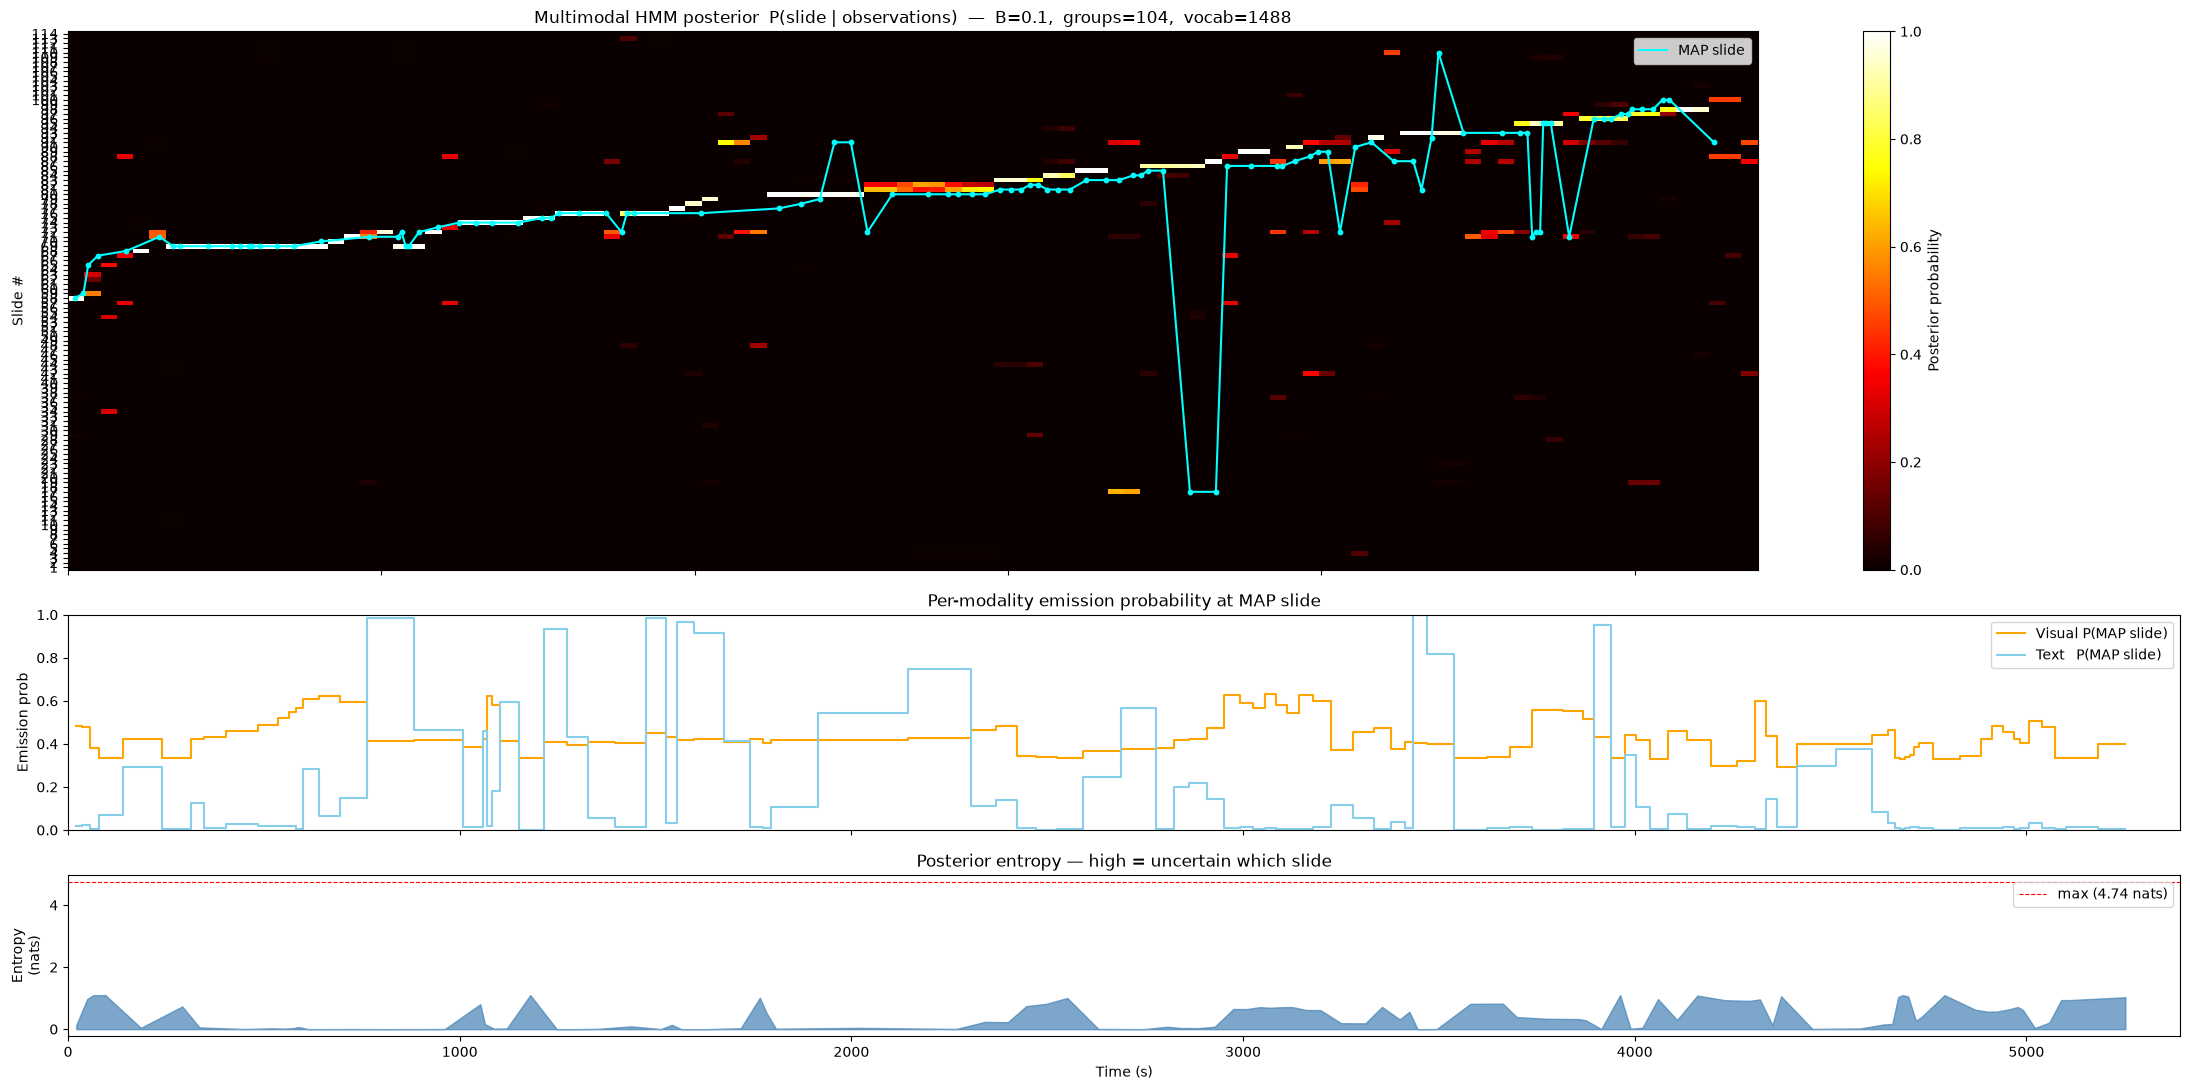

In [105]:
# ── Visualisation ─────────────────────────────────────────────────────────────
# Three-panel figure:
#   Top   : posterior heatmap (slide × group),  MAP path in cyan
#   Middle: individual modality contributions (visual vs text) for the MAP slide
#   Bottom: posterior entropy over time

group_mid = (group_starts + group_ends) / 2   # midpoint of each group for x-axis

fig, axes = plt.subplots(
    3, 1, figsize=(22, 11),
    gridspec_kw={'height_ratios': [5, 2, 1.5]},
    sharex=True
)

# ── Panel 1: full posterior heatmap ─────────────────────────────────────────
ax0 = axes[0]
im = ax0.imshow(
    posterior.T,                     # (S, G) — rows=slides, cols=groups
    aspect='auto',
    origin='lower',
    cmap='hot',
    vmin=0, vmax=1,
    extent=[group_starts[0], group_ends[-1], 0.5, n_slides + 0.5]
)
ax0.plot(group_mid, map_slide, color='cyan', lw=1.5, label='MAP slide')
ax0.scatter(group_mid, map_slide, color='cyan', s=10, zorder=4)
ax0.set_ylabel('Slide #')
ax0.set_yticks(range(1, n_slides+1))
ax0.set_title(
    f'Multimodal HMM posterior  P(slide | observations)  —  '
    f'B={B},  groups={n_groups},  vocab={V}'
)
ax0.legend(loc='upper right')
plt.colorbar(im, ax=ax0, label='Posterior probability')

# ── Panel 2: per-modality probability for the MAP slide ─────────────────────
ax1 = axes[1]
vis_at_map  = np.array([emit_vis[g,  map_slide[g]-1] for g in range(n_groups)])
text_at_map = np.array([emit_text[g, map_slide[g]-1] for g in range(n_groups)])
ax1.step(group_mid, vis_at_map,  where='mid', color='orange',  lw=1.5, label='Visual P(MAP slide)')
ax1.step(group_mid, text_at_map, where='mid', color='skyblue', lw=1.5, label='Text   P(MAP slide)')
ax1.set_ylabel('Emission prob')
ax1.set_ylim(0, 1)
ax1.legend(loc='upper right')
ax1.set_title('Per-modality emission probability at MAP slide')

# ── Panel 3: posterior entropy over groups ───────────────────────────────────
# Use np.where to guard log(0): entropy contribution of p=0 cells is 0.
ax2 = axes[2]
entropy = np.where(posterior > 0, -posterior * np.log(posterior), 0.0).sum(axis=1)
ax2.fill_between(group_mid, entropy, alpha=0.7, color='steelblue')
ax2.axhline(np.log(n_slides), color='red', lw=0.8, ls='--', label=f'max ({np.log(n_slides):.2f} nats)')
ax2.set_ylabel('Entropy\n(nats)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Posterior entropy — high = uncertain which slide')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

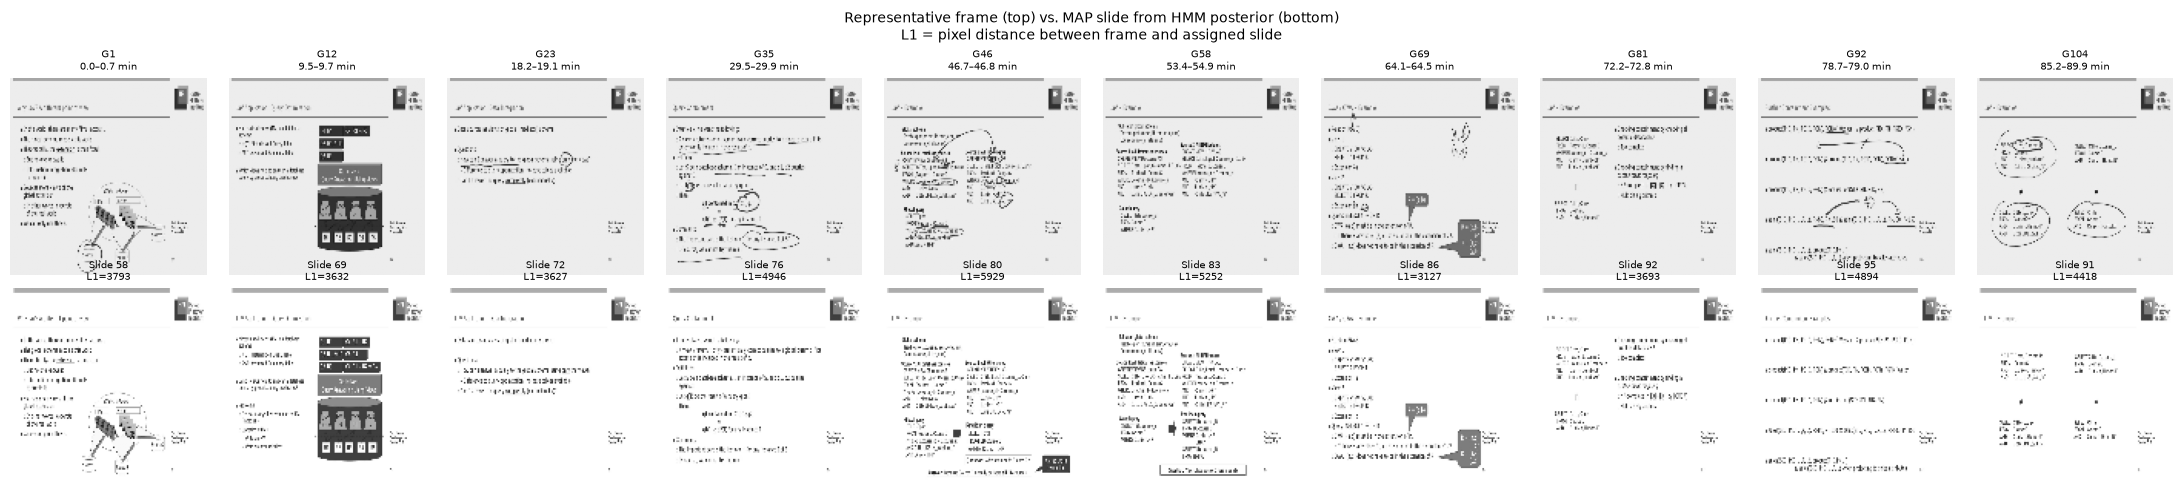

In [106]:
# ── Frame vs. most-likely slide: 10 evenly-spaced groups ─────────────────────

N_SHOW   = 10
show_idx = np.linspace(0, n_groups - 1, N_SHOW, dtype=int)

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2.2, 5))

for col, g in enumerate(show_idx):
    slide_idx   = map_slide[g] - 1
    frame_uint8 = groups[g]['frame']

    ax_top = axes[0, col]
    if frame_uint8 is not None:
        ax_top.imshow(frame_uint8, cmap='gray', vmin=0, vmax=255)
    else:
        ax_top.set_facecolor('black')
        ax_top.text(0.5, 0.5, 'no frame', color='white',
                    ha='center', va='center', transform=ax_top.transAxes)
    ax_top.set_title(
        f"G{g+1}\n{groups[g]['start_time']/60:.1f}–{groups[g]['end_time']/60:.1f} min",
        fontsize=7
    )
    ax_top.axis('off')

    ax_bot = axes[1, col]
    ax_bot.imshow(slides_raw[slide_idx], cmap='gray', vmin=0, vmax=255)
    ax_bot.set_title(
        f"Slide {slide_idx+1}\n"
        f"L1={l1_dists[g, slide_idx]:.0f}",
        fontsize=7
    )
    ax_bot.axis('off')

axes[0, 0].set_ylabel('Frame', fontsize=9)
axes[1, 0].set_ylabel('MAP slide', fontsize=9)
fig.suptitle(
    'Representative frame (top) vs. MAP slide from HMM posterior (bottom)\n'
    'L1 = pixel distance between frame and assigned slide',
    fontsize=10
)
plt.tight_layout()
plt.show()

/var/folders/00/ghmcvj4s1psckq_yqh3czg100000gn/T/ipykernel_45739/1353313294.py:6: RuntimeWarning: divide by zero encountered in log
  entropy = np.where(posterior > 0, -posterior * np.log(posterior), 0.0).sum(axis=1)
/var/folders/00/ghmcvj4s1psckq_yqh3czg100000gn/T/ipykernel_45739/1353313294.py:6: RuntimeWarning: invalid value encountered in multiply
  entropy = np.where(posterior > 0, -posterior * np.log(posterior), 0.0).sum(axis=1)


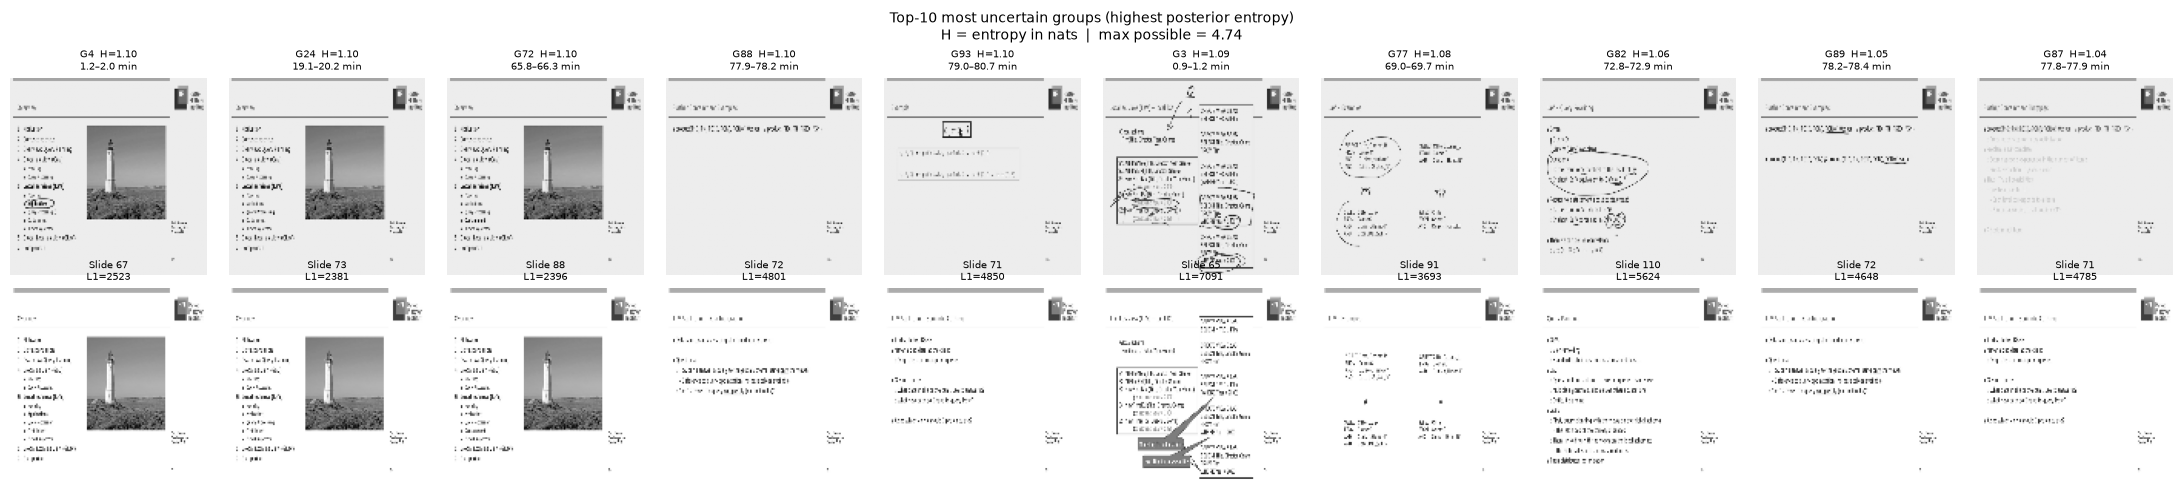

In [109]:
# ── Most uncertain assignments ────────────────────────────────────────────────
# Sort groups by posterior entropy (descending) and show the top-10.
# High entropy = the model was most unsure which slide this group belongs to.

N_SHOW = 10
entropy = np.where(posterior > 0, -posterior * np.log(posterior), 0.0).sum(axis=1)
top_uncertain = np.argsort(entropy)[::-1][:N_SHOW]   # highest entropy first

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2.2, 5))

for col, g in enumerate(top_uncertain):
    slide_idx   = map_slide[g] - 1
    frame_uint8 = groups[g]['frame']

    # ── top: video frame ──────────────────────────────────────────────────
    ax_top = axes[0, col]
    if frame_uint8 is not None:
        ax_top.imshow(frame_uint8, cmap='gray', vmin=0, vmax=255)
    else:
        ax_top.set_facecolor('black')
        ax_top.text(0.5, 0.5, 'no frame', color='white',
                    ha='center', va='center', transform=ax_top.transAxes)
    ax_top.set_title(
        f"G{g+1}  H={entropy[g]:.2f}\n"
        f"{groups[g]['start_time']/60:.1f}–{groups[g]['end_time']/60:.1f} min",
        fontsize=7
    )
    ax_top.axis('off')

    # ── bottom: MAP slide ─────────────────────────────────────────────────
    ax_bot = axes[1, col]
    ax_bot.imshow(slides_raw[slide_idx], cmap='gray', vmin=0, vmax=255)
    ax_bot.set_title(f"Slide {slide_idx+1}\nL1={l1_dists[g, slide_idx]:.0f}", fontsize=7)
    ax_bot.axis('off')

axes[0, 0].set_ylabel('Frame', fontsize=9)
axes[1, 0].set_ylabel('MAP slide', fontsize=9)
fig.suptitle(
    f'Top-{N_SHOW} most uncertain groups (highest posterior entropy)\n'
    f'H = entropy in nats  |  max possible = {np.log(n_slides):.2f}',
    fontsize=10
)
plt.tight_layout()
plt.show()

In [107]:
log_emit_vis[3]

array([       -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf, -1.10529733,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf, -1.09497499,        -inf,        -inf,      

<BarContainer object of 114 artists>

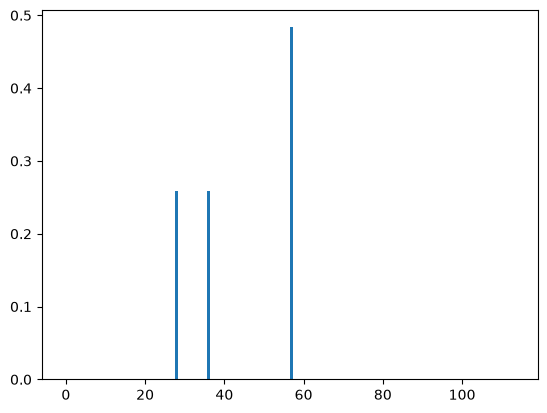

In [108]:
plt.bar(np.arange(len(log_emit_vis[0])),np.exp(log_emit_vis[0]))